### Imports

In [2]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import heapq
import random
import pandas as pd
from collections import defaultdict
from dataclasses import dataclass

### Environment Setup

In [3]:
ENV_NAME = "Taxi-v3"

env = gym.make(ENV_NAME)

N_STATES = env.observation_space.n
N_ACTIONS = env.action_space.n

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Number of states:", N_STATES)
print("Number of actions:", N_ACTIONS)

env.close()

Observation space: Discrete(500)
Action space: Discrete(6)
Number of states: 500
Number of actions: 6


### Utility Functions

In [4]:
def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)


def epsilon_greedy_action(Q, state, epsilon):
    if np.random.random() < epsilon:
        return np.random.choice(N_ACTIONS)

    return int(np.argmax(Q[state]))


def q_learning_update(Q, state, action, reward, next_state, terminated, alpha, gamma):
    if terminated:
        target = reward
    else:
        target = reward + gamma * np.max(Q[next_state])

    td_error = target - Q[state, action]
    Q[state, action] += alpha * td_error

    return td_error


def moving_average(data, window_size=100):
    data = np.asarray(data, dtype=np.float64)

    if len(data) < window_size:
        return data

    kernel = np.ones(window_size) / window_size
    return np.convolve(data, kernel, mode="valid")


def mean_and_95_ci(data):
    data = np.asarray(data, dtype=np.float64)

    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0, ddof=1)
    n = data.shape[0]

    ci = 1.96 * std / np.sqrt(n)

    return mean, ci

### Training Configuration

In [5]:
@dataclass
class DynaConfig:
    env_name: str = "Taxi-v3"
    num_episodes: int = 500
    max_steps_per_episode: int = 200
    alpha: float = 0.1
    gamma: float = 0.95
    epsilon: float = 0.1
    planning_steps: int = 0
    seed: int = 42

### Pure Q-learning and Dyna-Q

In [6]:
def train_dyna_q(config):
    """
    Dyna-Q with:
    1. Direct RL through real Q-learning updates
    2. Model learning with model[(s,a)] = (r, s', terminated)
    3. Planning through simulated Q-learning updates
    """

    set_seed(config.seed)

    env = gym.make(config.env_name)

    Q = np.zeros((N_STATES, N_ACTIONS), dtype=np.float64)

    model = {}

    episode_rewards = np.zeros(config.num_episodes, dtype=np.float64)
    episode_lengths = np.zeros(config.num_episodes, dtype=np.int64)

    cumulative_rewards_over_steps = []
    total_real_steps = 0
    cumulative_reward = 0.0

    for episode in range(config.num_episodes):
        state, info = env.reset(seed=config.seed + episode)

        total_episode_reward = 0.0

        for step in range(config.max_steps_per_episode):
            action = epsilon_greedy_action(Q, state, config.epsilon)

            next_state, reward, terminated, truncated, info = env.step(action)

            q_learning_update(
                Q=Q,
                state=state,
                action=action,
                reward=reward,
                next_state=next_state,
                terminated=terminated,
                alpha=config.alpha,
                gamma=config.gamma
            )

            model[(state, action)] = (reward, next_state, terminated)

            if len(model) > 0:
                model_keys = list(model.keys())

                for _ in range(config.planning_steps):
                    sim_state, sim_action = random.choice(model_keys)
                    sim_reward, sim_next_state, sim_terminated = model[(sim_state, sim_action)]

                    q_learning_update(
                        Q=Q,
                        state=sim_state,
                        action=sim_action,
                        reward=sim_reward,
                        next_state=sim_next_state,
                        terminated=sim_terminated,
                        alpha=config.alpha,
                        gamma=config.gamma
                    )

            state = next_state

            total_episode_reward += reward
            cumulative_reward += reward
            total_real_steps += 1
            cumulative_rewards_over_steps.append(cumulative_reward)

            if terminated or truncated:
                break

        episode_rewards[episode] = total_episode_reward
        episode_lengths[episode] = step + 1

    env.close()

    return {
        "Q": Q,
        "model": model,
        "episode_rewards": episode_rewards,
        "episode_lengths": episode_lengths,
        "cumulative_rewards_over_steps": np.array(cumulative_rewards_over_steps),
        "total_real_steps": total_real_steps,
        "config": config
    }

### Multi-Seed Runner for Dyna-Q

In [7]:
def run_dyna_q_multi_seed(
    planning_steps,
    seeds=np.arange(30),
    num_episodes=500,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1
):
    results = []

    for seed in seeds:
        print(f"Training Dyna-Q | planning_steps={planning_steps} | seed={seed}")

        config = DynaConfig(
            num_episodes=num_episodes,
            alpha=alpha,
            gamma=gamma,
            epsilon=epsilon,
            planning_steps=planning_steps,
            seed=int(seed)
        )

        result = train_dyna_q(config)
        results.append(result)

    episode_rewards = np.array([result["episode_rewards"] for result in results])
    episode_lengths = np.array([result["episode_lengths"] for result in results])

    return {
        "planning_steps": planning_steps,
        "results": results,
        "episode_rewards": episode_rewards,
        "episode_lengths": episode_lengths,
        "seeds": np.array(seeds)
    }

### Run Q-learning vs Dyna-Q Experiments

In [8]:
SEEDS = np.arange(30)
NUM_EPISODES = 500

planning_step_values = [0, 5, 10, 50]

dyna_experiments = {}

for n in planning_step_values:
    dyna_experiments[n] = run_dyna_q_multi_seed(
        planning_steps=n,
        seeds=SEEDS,
        num_episodes=NUM_EPISODES,
        alpha=0.1,
        gamma=0.95,
        epsilon=0.1
    )

Training Dyna-Q | planning_steps=0 | seed=0
Training Dyna-Q | planning_steps=0 | seed=1
Training Dyna-Q | planning_steps=0 | seed=2
Training Dyna-Q | planning_steps=0 | seed=3
Training Dyna-Q | planning_steps=0 | seed=4
Training Dyna-Q | planning_steps=0 | seed=5
Training Dyna-Q | planning_steps=0 | seed=6
Training Dyna-Q | planning_steps=0 | seed=7
Training Dyna-Q | planning_steps=0 | seed=8
Training Dyna-Q | planning_steps=0 | seed=9
Training Dyna-Q | planning_steps=0 | seed=10
Training Dyna-Q | planning_steps=0 | seed=11
Training Dyna-Q | planning_steps=0 | seed=12
Training Dyna-Q | planning_steps=0 | seed=13
Training Dyna-Q | planning_steps=0 | seed=14
Training Dyna-Q | planning_steps=0 | seed=15
Training Dyna-Q | planning_steps=0 | seed=16
Training Dyna-Q | planning_steps=0 | seed=17
Training Dyna-Q | planning_steps=0 | seed=18
Training Dyna-Q | planning_steps=0 | seed=19
Training Dyna-Q | planning_steps=0 | seed=20
Training Dyna-Q | planning_steps=0 | seed=21
Training Dyna-Q | pl

### Plotting Episode Return Curves with 95% Confidence Intervals

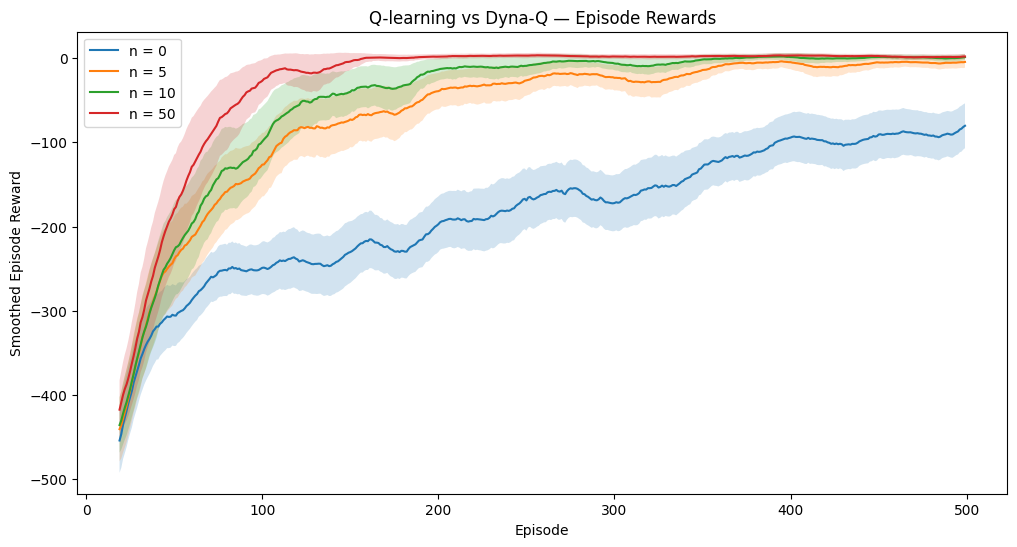

In [11]:
def plot_episode_returns_with_ci(experiments, window_size=20):
    plt.figure(figsize=(12, 6))

    for planning_steps, experiment in experiments.items():
        rewards = experiment["episode_rewards"]

        mean, ci = mean_and_95_ci(rewards)

        mean_smooth = moving_average(mean, window_size)
        ci_smooth = moving_average(ci, window_size)
        x = np.arange(len(mean_smooth)) + window_size - 1

        label = f"n = {planning_steps}"

        plt.plot(x, mean_smooth, label=label)
        plt.fill_between(
            x,
            mean_smooth - ci_smooth,
            mean_smooth + ci_smooth,
            alpha=0.2
        )

    plt.title("Q-learning vs Dyna-Q — Episode Rewards")
    plt.xlabel("Episode")
    plt.grid(False)
    plt.ylabel("Smoothed Episode Reward")
    plt.legend()
    plt.show()


plot_episode_returns_with_ci(dyna_experiments, window_size=20)

### Plotting Episode Length Curves with 95% Confidence Intervals

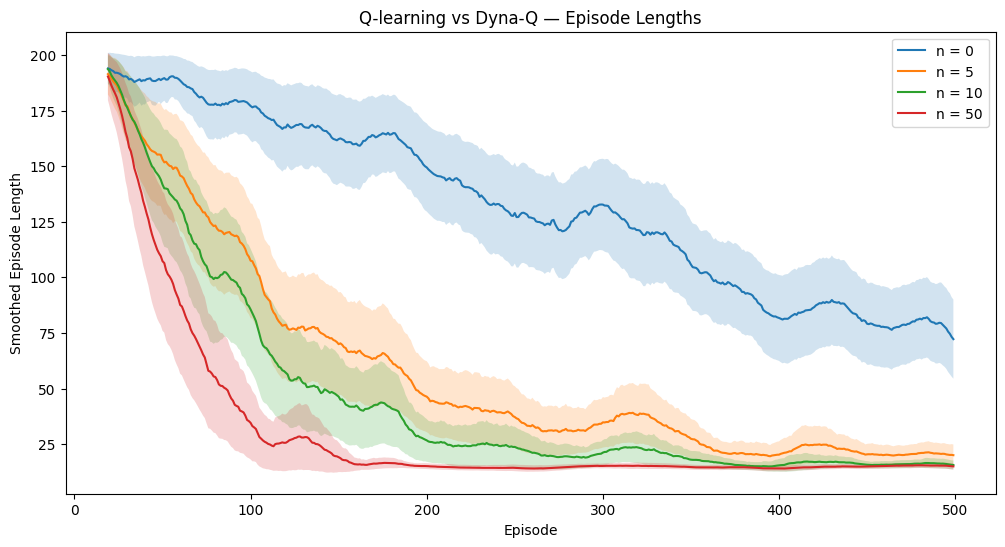

In [12]:
def plot_episode_lengths_with_ci(experiments, window_size=20):
    plt.figure(figsize=(12, 6))

    for planning_steps, experiment in experiments.items():
        lengths = experiment["episode_lengths"]

        mean, ci = mean_and_95_ci(lengths)

        mean_smooth = moving_average(mean, window_size)
        ci_smooth = moving_average(ci, window_size)
        x = np.arange(len(mean_smooth)) + window_size - 1

        label = f"n = {planning_steps}"

        plt.plot(x, mean_smooth, label=label)
        plt.fill_between(
            x,
            mean_smooth - ci_smooth,
            mean_smooth + ci_smooth,
            alpha=0.2
        )

    plt.title("Q-learning vs Dyna-Q — Episode Lengths")
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Episode Length")
    plt.legend()
    plt.grid(False)
    plt.show()


plot_episode_lengths_with_ci(dyna_experiments, window_size=20)

### Cumulative Reward Over Real Time Steps

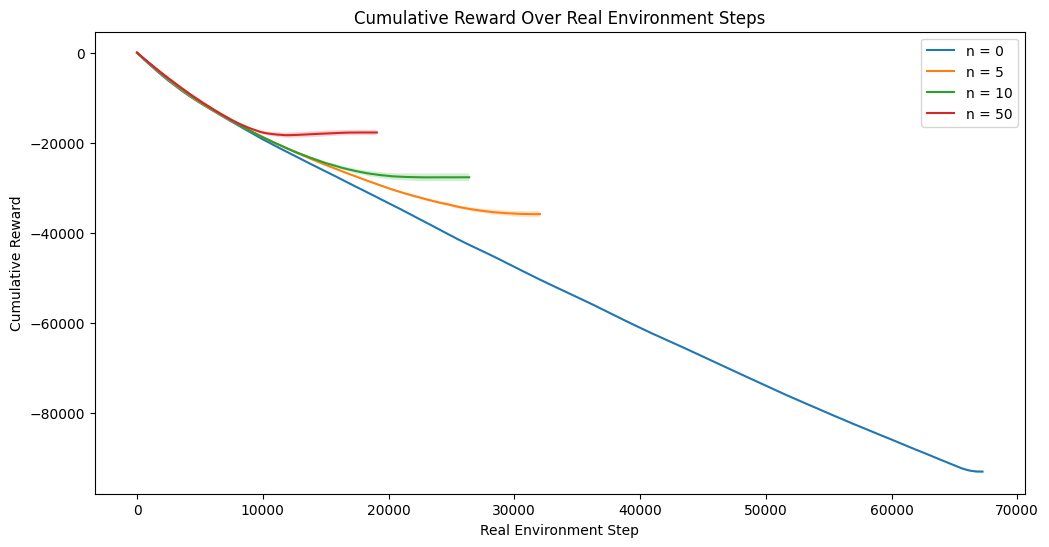

In [13]:
def pad_to_same_length(arrays):
    max_len = max(len(arr) for arr in arrays)

    padded = np.full((len(arrays), max_len), np.nan, dtype=np.float64)

    for i, arr in enumerate(arrays):
        padded[i, :len(arr)] = arr

        if len(arr) < max_len:
            padded[i, len(arr):] = arr[-1]

    return padded


def plot_cumulative_reward_over_real_steps(experiments):
    plt.figure(figsize=(12, 6))

    for planning_steps, experiment in experiments.items():
        cumulative_arrays = [
            result["cumulative_rewards_over_steps"]
            for result in experiment["results"]
        ]

        padded = pad_to_same_length(cumulative_arrays)

        mean = np.nanmean(padded, axis=0)
        std = np.nanstd(padded, axis=0, ddof=1)
        ci = 1.96 * std / np.sqrt(padded.shape[0])

        x = np.arange(len(mean))

        plt.plot(x, mean, label=f"n = {planning_steps}")
        plt.fill_between(x, mean - ci, mean + ci, alpha=0.2)

    plt.title("Cumulative Reward Over Real Environment Steps")
    plt.xlabel("Real Environment Step")
    plt.ylabel("Cumulative Reward")
    plt.legend()
    plt.grid(False)
    plt.show()


plot_cumulative_reward_over_real_steps(dyna_experiments)

### Performance Metrics

In [14]:
def compute_optimal_performance_episode(
    episode_rewards,
    reward_threshold=8,
    window_size=25
):

    smoothed = moving_average(episode_rewards, window_size)

    for idx, value in enumerate(smoothed):
        if value >= reward_threshold:
            return idx + window_size - 1

    return np.nan


def summarize_dyna_experiment(experiment, reward_threshold=8, window_size=25):
    rows = []

    planning_steps = experiment["planning_steps"]

    for result in experiment["results"]:
        rewards = result["episode_rewards"]
        lengths = result["episode_lengths"]

        episode_reaches_threshold = compute_optimal_performance_episode(
            rewards,
            reward_threshold=reward_threshold,
            window_size=window_size
        )

        if np.isnan(episode_reaches_threshold):
            real_steps_to_threshold = np.nan
        else:
            real_steps_to_threshold = np.sum(lengths[:int(episode_reaches_threshold) + 1])

        row = {
            "planning_steps": planning_steps,
            "final_avg_reward": np.mean(rewards[-50:]),
            "final_avg_length": np.mean(lengths[-50:]),
            "episode_reaches_threshold": episode_reaches_threshold,
            "real_steps_to_threshold": real_steps_to_threshold,
            "total_real_steps": result["total_real_steps"]
        }

        rows.append(row)

    return pd.DataFrame(rows)


PERFORMANCE_THRESHOLD = 0

summary_frames = []

for planning_steps, experiment in dyna_experiments.items():
    summary_frames.append(
        summarize_dyna_experiment(
            experiment,
            reward_threshold=PERFORMANCE_THRESHOLD,
            window_size=25
        )
    )

dyna_summary_raw_df = pd.concat(summary_frames, ignore_index=True)

dyna_summary_df = dyna_summary_raw_df.groupby("planning_steps").agg(
    final_avg_reward_mean=("final_avg_reward", "mean"),
    final_avg_reward_std=("final_avg_reward", "std"),
    final_avg_length_mean=("final_avg_length", "mean"),
    final_avg_length_std=("final_avg_length", "std"),
    episode_reaches_threshold_mean=("episode_reaches_threshold", "mean"),
    real_steps_to_threshold_mean=("real_steps_to_threshold", "mean"),
    total_real_steps_mean=("total_real_steps", "mean")
).reset_index()

dyna_summary_df

,planning_steps,final_avg_reward_mean,final_avg_reward_std,final_avg_length_mean,final_avg_length_std,episode_reaches_threshold_mean,real_steps_to_threshold_mean,total_real_steps_mean
0,0,-86.247333,4.697578,76.537333,2.689601,NaN,NaN,66262.133333
1,5,-5.035333,2.045049,20.365333,1.461760,389.250000,27200.200000,29765.033333
2,10,0.809333,1.476732,15.900667,0.640161,289.166667,19836.233333,23488.766667
3,50,1.510667,1.035757,15.205333,0.319350,138.733333,11051.566667,16495.900000


### Plotting Real Environment Interactions Needed

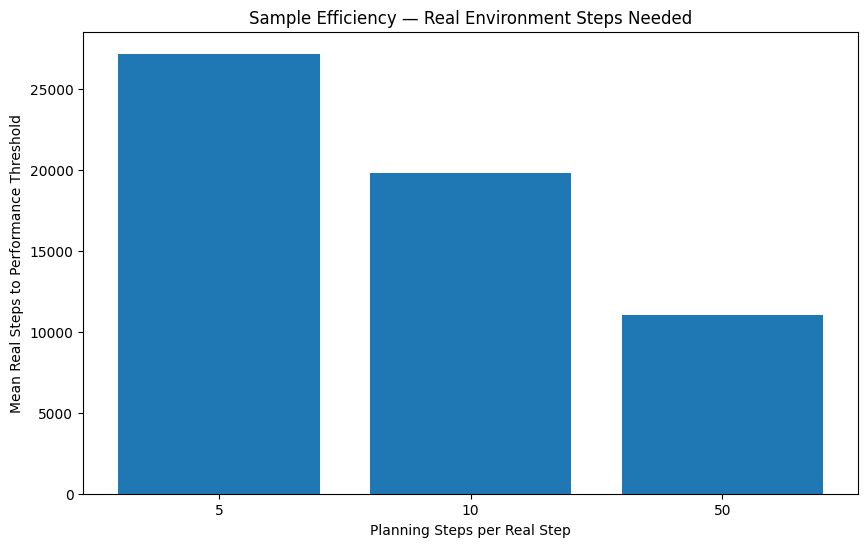

In [15]:
def plot_sample_efficiency(summary_df):
    plt.figure(figsize=(10, 6))

    x = summary_df["planning_steps"].astype(str)
    y = summary_df["real_steps_to_threshold_mean"]

    plt.bar(x, y)

    plt.title("Sample Efficiency — Real Environment Steps Needed")
    plt.xlabel("Planning Steps per Real Step")
    plt.ylabel("Mean Real Steps to Performance Threshold")
    plt.grid(axis="y")
    plt.grid(False)
    plt.show()


plot_sample_efficiency(dyna_summary_df)

### Dynamic Taxi Wrapper

In [16]:
class DynamicTaxiWrapper(gym.Wrapper):

    def __init__(
        self,
        env,
        change_step=1000,
        penalty_states=None,
        penalty_action=1,
        extra_penalty=-20
    ):
        super().__init__(env)

        self.change_step = change_step
        self.global_step_count = 0
        self.penalty_action = penalty_action
        self.extra_penalty = extra_penalty

        if penalty_states is None:
            self.penalty_states = set(range(100, 200))
        else:
            self.penalty_states = set(penalty_states)

        self.changed = False

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        self.global_step_count += 1

        if self.global_step_count >= self.change_step:
            self.changed = True

        if self.changed:
            if obs in self.penalty_states and action == self.penalty_action:
                reward += self.extra_penalty

        return obs, reward, terminated, truncated, info

### Dyna-Q and Dyna-Q+ in Dynamic Environment

In [17]:
@dataclass
class DynaPlusConfig:
    env_name: str = "Taxi-v3"
    num_episodes: int = 500
    max_steps_per_episode: int = 200
    alpha: float = 0.1
    gamma: float = 0.95
    epsilon: float = 0.1
    planning_steps: int = 10
    kappa: float = 0.001
    use_dyna_plus: bool = False
    change_step: int = 1000
    seed: int = 42


def train_dyna_q_dynamic(config):
    set_seed(config.seed)

    base_env = gym.make(config.env_name)

    env = DynamicTaxiWrapper(
        base_env,
        change_step=config.change_step,
        penalty_states=set(range(100, 200)),
        penalty_action=1,
        extra_penalty=-20
    )

    Q = np.zeros((N_STATES, N_ACTIONS), dtype=np.float64)

    model = {}
    time_since = defaultdict(int)

    episode_rewards = np.zeros(config.num_episodes, dtype=np.float64)
    episode_lengths = np.zeros(config.num_episodes, dtype=np.int64)

    cumulative_rewards_over_steps = []
    cumulative_reward = 0.0
    total_real_steps = 0

    reward_after_change = []

    for episode in range(config.num_episodes):
        state, info = env.reset(seed=config.seed + episode)

        total_episode_reward = 0.0

        for step in range(config.max_steps_per_episode):
            for key in list(time_since.keys()):
                time_since[key] += 1

            action = epsilon_greedy_action(Q, state, config.epsilon)

            next_state, reward, terminated, truncated, info = env.step(action)

            q_learning_update(
                Q=Q,
                state=state,
                action=action,
                reward=reward,
                next_state=next_state,
                terminated=terminated,
                alpha=config.alpha,
                gamma=config.gamma
            )

            model[(state, action)] = (reward, next_state, terminated)
            time_since[(state, action)] = 0

            model_keys = list(model.keys())

            for _ in range(config.planning_steps):
                sim_state, sim_action = random.choice(model_keys)
                sim_reward, sim_next_state, sim_terminated = model[(sim_state, sim_action)]

                if config.use_dyna_plus:
                    tau = time_since[(sim_state, sim_action)]
                    sim_reward = sim_reward + config.kappa * np.sqrt(tau)

                q_learning_update(
                    Q=Q,
                    state=sim_state,
                    action=sim_action,
                    reward=sim_reward,
                    next_state=sim_next_state,
                    terminated=sim_terminated,
                    alpha=config.alpha,
                    gamma=config.gamma
                )

            state = next_state

            total_episode_reward += reward
            cumulative_reward += reward
            total_real_steps += 1
            cumulative_rewards_over_steps.append(cumulative_reward)

            if env.changed:
                reward_after_change.append(reward)

            if terminated or truncated:
                break

        episode_rewards[episode] = total_episode_reward
        episode_lengths[episode] = step + 1

    env.close()

    return {
        "Q": Q,
        "model": model,
        "time_since": dict(time_since),
        "episode_rewards": episode_rewards,
        "episode_lengths": episode_lengths,
        "cumulative_rewards_over_steps": np.array(cumulative_rewards_over_steps),
        "total_real_steps": total_real_steps,
        "reward_after_change": np.array(reward_after_change),
        "config": config
    }

### Run Dynamic Environment Experiments

In [18]:
def run_dynamic_multi_seed(
    use_dyna_plus,
    seeds=np.arange(30),
    num_episodes=500,
    planning_steps=10,
    kappa=0.001,
    change_step=1000
):
    results = []

    for seed in seeds:
        label = "Dyna-Q+" if use_dyna_plus else "Dyna-Q"
        print(f"Training {label} | seed={seed}")

        config = DynaPlusConfig(
            num_episodes=num_episodes,
            planning_steps=planning_steps,
            kappa=kappa,
            use_dyna_plus=use_dyna_plus,
            change_step=change_step,
            seed=int(seed)
        )

        result = train_dyna_q_dynamic(config)
        results.append(result)

    episode_rewards = np.array([result["episode_rewards"] for result in results])
    episode_lengths = np.array([result["episode_lengths"] for result in results])

    return {
        "algorithm": "Dyna-Q+" if use_dyna_plus else "Dyna-Q",
        "results": results,
        "episode_rewards": episode_rewards,
        "episode_lengths": episode_lengths,
        "seeds": np.array(seeds)
    }


dynamic_dyna_q = run_dynamic_multi_seed(
    use_dyna_plus=False,
    seeds=SEEDS,
    num_episodes=500,
    planning_steps=10,
    kappa=0.001,
    change_step=1000
)

dynamic_dyna_q_plus = run_dynamic_multi_seed(
    use_dyna_plus=True,
    seeds=SEEDS,
    num_episodes=500,
    planning_steps=10,
    kappa=0.001,
    change_step=1000
)

Training Dyna-Q | seed=0
Training Dyna-Q | seed=1
Training Dyna-Q | seed=2
Training Dyna-Q | seed=3
Training Dyna-Q | seed=4
Training Dyna-Q | seed=5
Training Dyna-Q | seed=6
Training Dyna-Q | seed=7
Training Dyna-Q | seed=8
Training Dyna-Q | seed=9
Training Dyna-Q | seed=10
Training Dyna-Q | seed=11
Training Dyna-Q | seed=12
Training Dyna-Q | seed=13
Training Dyna-Q | seed=14
Training Dyna-Q | seed=15
Training Dyna-Q | seed=16
Training Dyna-Q | seed=17
Training Dyna-Q | seed=18
Training Dyna-Q | seed=19
Training Dyna-Q | seed=20
Training Dyna-Q | seed=21
Training Dyna-Q | seed=22
Training Dyna-Q | seed=23
Training Dyna-Q | seed=24
Training Dyna-Q | seed=25
Training Dyna-Q | seed=26
Training Dyna-Q | seed=27
Training Dyna-Q | seed=28
Training Dyna-Q | seed=29
Training Dyna-Q+ | seed=0
Training Dyna-Q+ | seed=1
Training Dyna-Q+ | seed=2
Training Dyna-Q+ | seed=3
Training Dyna-Q+ | seed=4
Training Dyna-Q+ | seed=5
Training Dyna-Q+ | seed=6
Training Dyna-Q+ | seed=7
Training Dyna-Q+ | see

### Plotting Dymanic Environment Adaptation

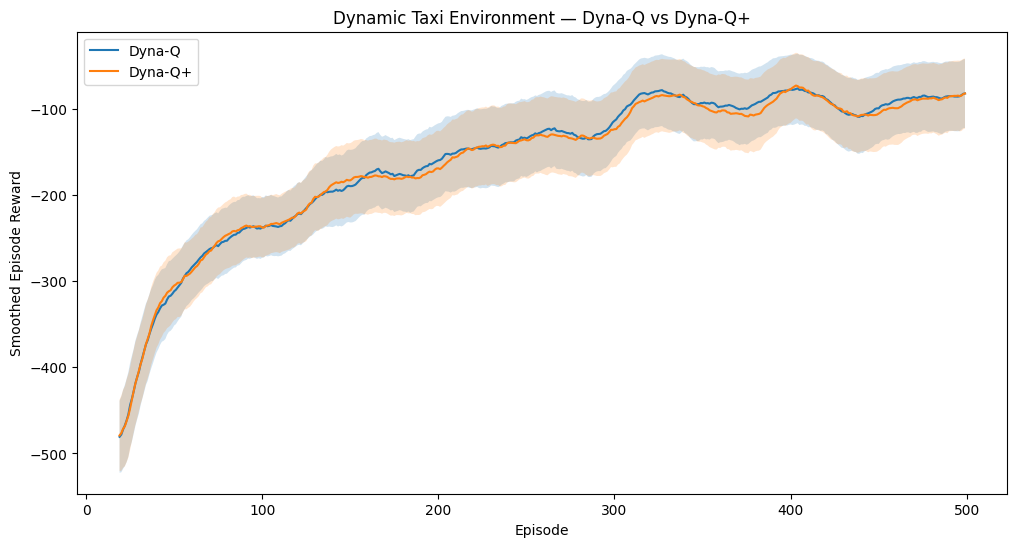

In [20]:
def plot_dynamic_adaptation(experiments, window_size=20):
    plt.figure(figsize=(12, 6))

    for experiment in experiments:
        rewards = experiment["episode_rewards"]

        mean, ci = mean_and_95_ci(rewards)

        mean_smooth = moving_average(mean, window_size)
        ci_smooth = moving_average(ci, window_size)
        x = np.arange(len(mean_smooth)) + window_size - 1

        plt.plot(x, mean_smooth, label=experiment["algorithm"])
        plt.fill_between(
            x,
            mean_smooth - ci_smooth,
            mean_smooth + ci_smooth,
            alpha=0.2
        )
    plt.grid(False)
    plt.title("Dynamic Taxi Environment — Dyna-Q vs Dyna-Q+")
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Episode Reward")
    plt.legend()
    plt.grid(False)
    plt.show()


plot_dynamic_adaptation(
    [dynamic_dyna_q, dynamic_dyna_q_plus],
    window_size=20
)

### Prioritized Sweeping Configuration

In [21]:
@dataclass
class PrioritizedSweepingConfig:
    env_name: str = "Taxi-v3"
    num_episodes: int = 500
    max_steps_per_episode: int = 200
    alpha: float = 0.1
    gamma: float = 0.95
    epsilon: float = 0.1
    planning_steps: int = 10
    theta: float = 1e-5
    seed: int = 42

### Prioritize Sweeping

In [22]:
def train_prioritized_sweeping(config):
    set_seed(config.seed)

    env = gym.make(config.env_name)

    Q = np.zeros((N_STATES, N_ACTIONS), dtype=np.float64)

    model = {}
    predecessors = defaultdict(set)

    priority_queue = []
    queued_pairs = set()

    episode_rewards = np.zeros(config.num_episodes, dtype=np.float64)
    episode_lengths = np.zeros(config.num_episodes, dtype=np.int64)

    cumulative_rewards_over_steps = []
    cumulative_reward = 0.0
    total_real_steps = 0

    def push_priority(state, action, priority):
        if priority > config.theta:
            heapq.heappush(priority_queue, (-priority, state, action))
            queued_pairs.add((state, action))

    for episode in range(config.num_episodes):
        state, info = env.reset(seed=config.seed + episode)

        total_episode_reward = 0.0

        for step in range(config.max_steps_per_episode):
            action = epsilon_greedy_action(Q, state, config.epsilon)

            next_state, reward, terminated, truncated, info = env.step(action)

            model[(state, action)] = (reward, next_state, terminated)
            predecessors[next_state].add((state, action))

            if terminated:
                target = reward
            else:
                target = reward + config.gamma * np.max(Q[next_state])

            priority = abs(target - Q[state, action])
            push_priority(state, action, priority)

            planning_count = 0

            while priority_queue and planning_count < config.planning_steps:
                negative_priority, plan_state, plan_action = heapq.heappop(priority_queue)

                if (plan_state, plan_action) in queued_pairs:
                    queued_pairs.remove((plan_state, plan_action))

                plan_reward, plan_next_state, plan_terminated = model[(plan_state, plan_action)]

                q_learning_update(
                    Q=Q,
                    state=plan_state,
                    action=plan_action,
                    reward=plan_reward,
                    next_state=plan_next_state,
                    terminated=plan_terminated,
                    alpha=config.alpha,
                    gamma=config.gamma
                )

                for pred_state, pred_action in predecessors[plan_state]:
                    pred_reward, pred_next_state, pred_terminated = model[(pred_state, pred_action)]

                    if pred_terminated:
                        pred_target = pred_reward
                    else:
                        pred_target = pred_reward + config.gamma * np.max(Q[pred_next_state])

                    pred_priority = abs(pred_target - Q[pred_state, pred_action])
                    push_priority(pred_state, pred_action, pred_priority)

                planning_count += 1

            state = next_state

            total_episode_reward += reward
            cumulative_reward += reward
            total_real_steps += 1
            cumulative_rewards_over_steps.append(cumulative_reward)

            if terminated or truncated:
                break

        episode_rewards[episode] = total_episode_reward
        episode_lengths[episode] = step + 1

    env.close()

    return {
        "Q": Q,
        "model": model,
        "predecessors": predecessors,
        "episode_rewards": episode_rewards,
        "episode_lengths": episode_lengths,
        "cumulative_rewards_over_steps": np.array(cumulative_rewards_over_steps),
        "total_real_steps": total_real_steps,
        "config": config
    }

### Run Prioritized Sweeping Multi-Seed Experiment

In [23]:
def run_prioritized_sweeping_multi_seed(
    seeds=np.arange(30),
    num_episodes=500,
    planning_steps=10,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1,
    theta=1e-5
):
    results = []

    for seed in seeds:
        print(f"Training Prioritized Sweeping | seed={seed}")

        config = PrioritizedSweepingConfig(
            num_episodes=num_episodes,
            planning_steps=planning_steps,
            alpha=alpha,
            gamma=gamma,
            epsilon=epsilon,
            theta=theta,
            seed=int(seed)
        )

        result = train_prioritized_sweeping(config)
        results.append(result)

    episode_rewards = np.array([result["episode_rewards"] for result in results])
    episode_lengths = np.array([result["episode_lengths"] for result in results])

    return {
        "algorithm": "Prioritized Sweeping",
        "results": results,
        "episode_rewards": episode_rewards,
        "episode_lengths": episode_lengths,
        "seeds": np.array(seeds)
    }


prioritized_sweeping_result = run_prioritized_sweeping_multi_seed(
    seeds=SEEDS,
    num_episodes=500,
    planning_steps=10,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1,
    theta=1e-5
)

Training Prioritized Sweeping | seed=0
Training Prioritized Sweeping | seed=1
Training Prioritized Sweeping | seed=2
Training Prioritized Sweeping | seed=3
Training Prioritized Sweeping | seed=4
Training Prioritized Sweeping | seed=5
Training Prioritized Sweeping | seed=6
Training Prioritized Sweeping | seed=7
Training Prioritized Sweeping | seed=8
Training Prioritized Sweeping | seed=9
Training Prioritized Sweeping | seed=10
Training Prioritized Sweeping | seed=11
Training Prioritized Sweeping | seed=12
Training Prioritized Sweeping | seed=13
Training Prioritized Sweeping | seed=14
Training Prioritized Sweeping | seed=15
Training Prioritized Sweeping | seed=16
Training Prioritized Sweeping | seed=17
Training Prioritized Sweeping | seed=18
Training Prioritized Sweeping | seed=19
Training Prioritized Sweeping | seed=20
Training Prioritized Sweeping | seed=21
Training Prioritized Sweeping | seed=22
Training Prioritized Sweeping | seed=23
Training Prioritized Sweeping | seed=24
Training P

### Comparing Uniform Planning vs Prioritized Sweeping

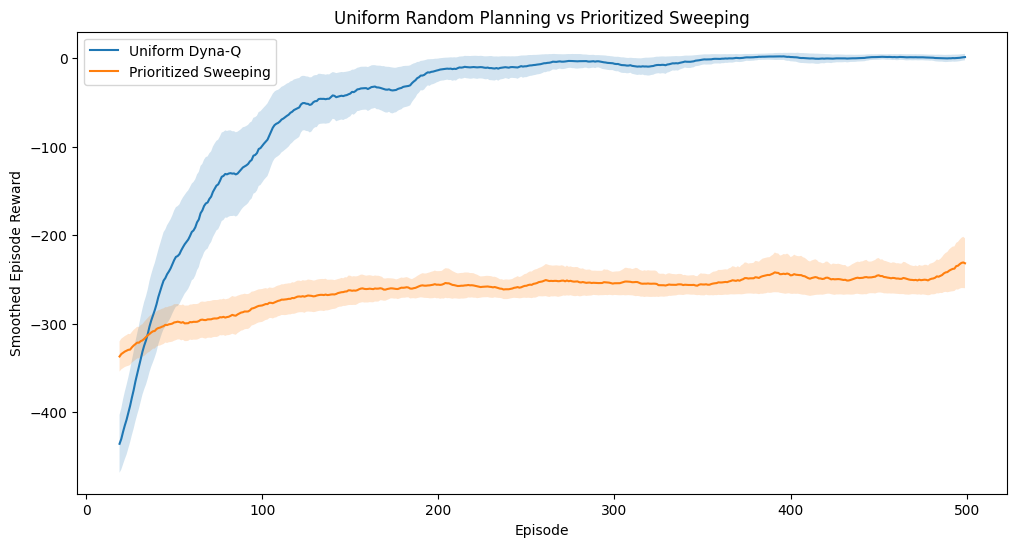

In [24]:
uniform_dyna_10 = {
    "algorithm": "Uniform Dyna-Q",
    "episode_rewards": dyna_experiments[10]["episode_rewards"],
    "episode_lengths": dyna_experiments[10]["episode_lengths"],
    "results": dyna_experiments[10]["results"]
}

def plot_uniform_vs_prioritized(uniform_result, prioritized_result, window_size=20):
    plt.figure(figsize=(12, 6))

    for experiment in [uniform_result, prioritized_result]:
        rewards = experiment["episode_rewards"]

        mean, ci = mean_and_95_ci(rewards)

        mean_smooth = moving_average(mean, window_size)
        ci_smooth = moving_average(ci, window_size)
        x = np.arange(len(mean_smooth)) + window_size - 1

        plt.plot(x, mean_smooth, label=experiment["algorithm"])
        plt.fill_between(
            x,
            mean_smooth - ci_smooth,
            mean_smooth + ci_smooth,
            alpha=0.2
        )

    plt.title("Uniform Random Planning vs Prioritized Sweeping")
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Episode Reward")
    plt.legend()
    plt.grid(False)
    plt.show()


plot_uniform_vs_prioritized(
    uniform_result=uniform_dyna_10,
    prioritized_result=prioritized_sweeping_result,
    window_size=20
)

### Prioritized Sweeping Episode Lenght Comparison

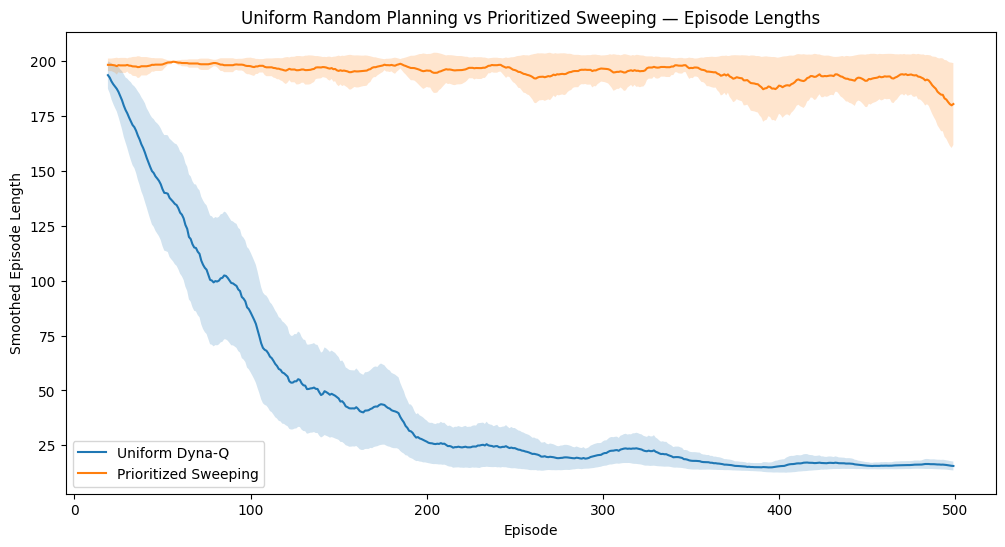

In [25]:
def plot_uniform_vs_prioritized_lengths(uniform_result, prioritized_result, window_size=20):
    plt.figure(figsize=(12, 6))

    for experiment in [uniform_result, prioritized_result]:
        lengths = experiment["episode_lengths"]

        mean, ci = mean_and_95_ci(lengths)

        mean_smooth = moving_average(mean, window_size)
        ci_smooth = moving_average(ci, window_size)
        x = np.arange(len(mean_smooth)) + window_size - 1

        plt.plot(x, mean_smooth, label=experiment["algorithm"])
        plt.fill_between(
            x,
            mean_smooth - ci_smooth,
            mean_smooth + ci_smooth,
            alpha=0.2
        )

    plt.title("Uniform Random Planning vs Prioritized Sweeping — Episode Lengths")
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Episode Length")
    plt.legend()
    plt.grid(False)
    plt.show()


plot_uniform_vs_prioritized_lengths(
    uniform_result=uniform_dyna_10,
    prioritized_result=prioritized_sweeping_result,
    window_size=20
)

### Policy Extraction and Evaluation

In [26]:
def evaluate_greedy_policy(Q, num_eval_episodes=100, seed=999):
    env = gym.make("Taxi-v3")

    rewards = np.zeros(num_eval_episodes, dtype=np.float64)
    lengths = np.zeros(num_eval_episodes, dtype=np.int64)
    successes = np.zeros(num_eval_episodes, dtype=bool)

    for episode in range(num_eval_episodes):
        state, info = env.reset(seed=seed + episode)

        total_reward = 0.0

        for step in range(200):
            action = int(np.argmax(Q[state]))

            next_state, reward, terminated, truncated, info = env.step(action)

            total_reward += reward
            state = next_state

            if terminated:
                successes[episode] = True
                break

            if truncated:
                break

        rewards[episode] = total_reward
        lengths[episode] = step + 1

    env.close()

    return {
        "mean_reward": np.mean(rewards),
        "std_reward": np.std(rewards, ddof=1),
        "mean_length": np.mean(lengths),
        "std_length": np.std(lengths, ddof=1),
        "success_rate": np.mean(successes),
        "rewards": rewards,
        "lengths": lengths,
        "successes": successes
    }

### Final Comparison Table

In [27]:
def summarize_result_group(name, result_group, final_window=50):
    rows = []

    for result in result_group["results"]:
        Q = result["Q"]
        eval_stats = evaluate_greedy_policy(Q)

        rewards = result["episode_rewards"]
        lengths = result["episode_lengths"]

        row = {
            "Algorithm": name,
            "Final Avg Reward": np.mean(rewards[-final_window:]),
            "Final Avg Length": np.mean(lengths[-final_window:]),
            "Eval Mean Reward": eval_stats["mean_reward"],
            "Eval Mean Length": eval_stats["mean_length"],
            "Eval Success Rate": eval_stats["success_rate"],
            "Total Real Steps": result["total_real_steps"]
        }

        rows.append(row)

    return pd.DataFrame(rows)


comparison_groups = []

for planning_steps, experiment in dyna_experiments.items():
    comparison_groups.append(
        summarize_result_group(
            name=f"Dyna-Q n={planning_steps}",
            result_group=experiment
        )
    )

comparison_groups.append(
    summarize_result_group(
        name="Prioritized Sweeping",
        result_group=prioritized_sweeping_result
    )
)

final_comparison_raw_df = pd.concat(comparison_groups, ignore_index=True)

final_comparison_df = final_comparison_raw_df.groupby("Algorithm").agg(
    final_avg_reward_mean=("Final Avg Reward", "mean"),
    final_avg_reward_std=("Final Avg Reward", "std"),
    final_avg_length_mean=("Final Avg Length", "mean"),
    eval_mean_reward_mean=("Eval Mean Reward", "mean"),
    eval_mean_length_mean=("Eval Mean Length", "mean"),
    eval_success_rate_mean=("Eval Success Rate", "mean"),
    total_real_steps_mean=("Total Real Steps", "mean")
).reset_index()

final_comparison_df

,Algorithm,final_avg_reward_mean,final_avg_reward_std,final_avg_length_mean,eval_mean_reward_mean,eval_mean_length_mean,eval_success_rate_mean,total_real_steps_mean
0,Dyna-Q n=0,-86.247333,4.697578,76.537333,-237.382000,179.359000,0.108000,66262.133333
1,Dyna-Q n=10,0.809333,1.476732,15.900667,-18.225667,36.565667,0.873333,23488.766667
2,Dyna-Q n=5,-5.035333,2.045049,20.365333,-65.796333,79.271333,0.641667,29765.033333
3,Dyna-Q n=50,1.510667,1.035757,15.205333,7.580667,13.412333,0.999667,16495.900000
4,Prioritized Sweeping,-242.866667,9.682488,188.368667,-190.354333,190.778333,0.048333,97494.666667


### Dynamic Environment Comparison Table

In [28]:
dynamic_comparison_raw_df = pd.concat(
    [
        summarize_result_group("Dyna-Q Dynamic", dynamic_dyna_q),
        summarize_result_group("Dyna-Q+ Dynamic", dynamic_dyna_q_plus)
    ],
    ignore_index=True
)

dynamic_comparison_df = dynamic_comparison_raw_df.groupby("Algorithm").agg(
    final_avg_reward_mean=("Final Avg Reward", "mean"),
    final_avg_reward_std=("Final Avg Reward", "std"),
    final_avg_length_mean=("Final Avg Length", "mean"),
    eval_mean_reward_mean=("Eval Mean Reward", "mean"),
    eval_mean_length_mean=("Eval Mean Length", "mean"),
    eval_success_rate_mean=("Eval Success Rate", "mean"),
    total_real_steps_mean=("Total Real Steps", "mean")
).reset_index()

dynamic_comparison_df

,Algorithm,final_avg_reward_mean,final_avg_reward_std,final_avg_length_mean,eval_mean_reward_mean,eval_mean_length_mean,eval_success_rate_mean,total_real_steps_mean
0,Dyna-Q Dynamic,-85.190000,10.671859,67.056667,-74.267667,86.888667,0.601000,56443.2
1,Dyna-Q+ Dynamic,-87.422667,11.978546,68.442667,-74.342333,86.956333,0.600667,57334.8


### Plotting the Final Average Reward Bar Chart

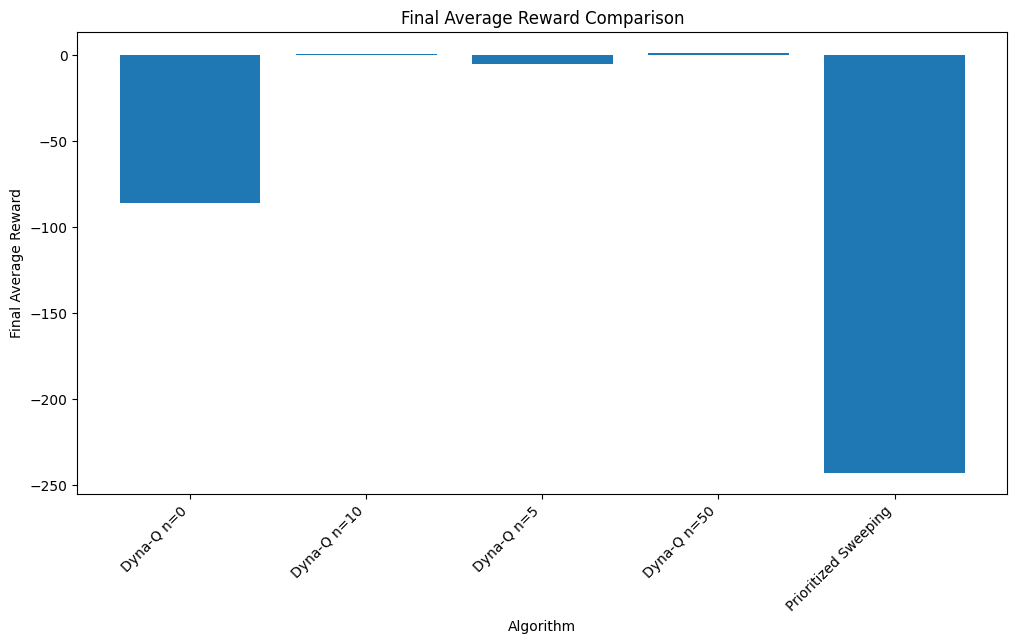

In [29]:
def plot_final_comparison_bar(summary_df):
    plt.figure(figsize=(12, 6))

    labels = summary_df["Algorithm"]
    values = summary_df["final_avg_reward_mean"]

    plt.bar(labels, values)

    plt.title("Final Average Reward Comparison")
    plt.xlabel("Algorithm")
    plt.ylabel("Final Average Reward")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y")
    plt.grid(False)
    plt.show()


plot_final_comparison_bar(final_comparison_df)

### Taxi State for Policy Inspection Decoding

In [30]:
def decode_taxi_state(state):

    env = gym.make("Taxi-v3")
    decoded = list(env.unwrapped.decode(state))
    env.close()

    return decoded


def inspect_policy(Q, num_states=20):
    policy = np.argmax(Q, axis=1)

    rows = []

    for state in range(num_states):
        decoded = decode_taxi_state(state)

        rows.append(
            {
                "State": state,
                "Taxi Row": decoded[0],
                "Taxi Col": decoded[1],
                "Passenger Location": decoded[2],
                "Destination": decoded[3],
                "Greedy Action": policy[state]
            }
        )

    return pd.DataFrame(rows)


best_q = dyna_experiments[50]["results"][0]["Q"]

policy_inspection_df = inspect_policy(best_q, num_states=20)

policy_inspection_df

,State,Taxi Row,Taxi Col,Passenger Location,Destination,Greedy Action
0,0,0,0,0,0,0
1,1,0,0,0,1,4
2,2,0,0,0,2,4
3,3,0,0,0,3,4
4,4,0,0,1,0,2
5,5,0,0,1,1,0
6,6,0,0,1,2,0
7,7,0,0,1,3,2
8,8,0,0,2,0,0
9,9,0,0,2,1,0
